# 手撕蒙特卡洛方法

In [2]:
import gymnasium as gym
import random
import numpy as np

In [3]:
print("gym version: ", gym.__version__)

gym version:  1.2.3


In [2]:
%%html
<img src="img/FrozenLake.png", width=300,height=150>

### 回报值计算公式：
$$
\begin{aligned}
\mathcal{Q}_{\pi}(s,a) & =\mathbb{E}_{\pi}[G_{t}|S_{t}=s,A_{t}=a] \\
 & =\mathbb{E}_{\pi}[\sum_{k=0}^{\infty}\gamma^{k}R_{t+k+1}\mid S_{t}=s,A_{t}=a] \\
 & =\mathbb{E}_\pi[(R_{t+1}+\gamma^1R_{t+2}+\gamma^2R_{t+3}+...+\gamma^kR_{t+k+1})\mid S_t=\mathrm{s},A_t=\alpha]
\end{aligned}
$$

In [3]:
# 引入环境：“冰湖”
env = gym.make("FrozenLake-v1", is_slippery=False)

In [4]:
env.observation_space, env.action_space

(Discrete(16), Discrete(4))

In [5]:
state = env.reset()
state

(0, {'prob': 1})

In [6]:
next_state, reward, done, truncated, info = env.step(0)
next_state, reward, done, truncated, info

(0, 0, False, False, {'prob': 1.0})

# 核心代码实现

In [7]:
def choose_action(state, q_table, epsilon, n_actions):
    """ ε-greedy action selection """
    if np.random.rand() < epsilon:
        return np.random.choice(n_actions)
    return np.argmax(q_table[state])

In [8]:
def monte_carlo(n_episode, env, gamma, epsilon=1.0, epsilon_decay=0.999, min_epsilon=0.05, max_steps=100):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    visit_count = np.zeros([n_states, n_actions])  # 记录每一个state出现的次数
    q_values = np.zeros([n_states, n_actions])  # 计算累计的 Q 值
    
    rewards_per_episode = []
    for episode in range(n_episode):  # 跑n_episode个回合
        state, _ = env.reset()  # 初始化环境
        episode_seqs = []  # 存储每次交互的数据，tuple=(state, action, reward)
        
        for _ in range(max_steps):
            action = choose_action(state, q_values, epsilon, n_actions)
            next_state, reward, terminated, truncated, _  = env.step(action)  # 执行动作
            done = terminated or truncated
            
            episode_seqs.append((state, action, reward)) # 保存每一个回合的reward
            state = next_state
            if done:
                break

        gain = 0
        for s, a, r in reversed(episode_seqs): # 倒着计算，计算累计收益 从回合的最后一步开始，一步步往回退到第一步
            gain = r + gamma * gain
            visit_count[s][a] += 1
            q_values[s][a] += (gain - q_values[s][a]) / visit_count[s][a] #增量更新
            ac = np.argmax(q_values[s]) # 根据最优贝尔曼策略，找到q值最大的对应的动作 找到最牛的s

        epsilon = max(min_epsilon, epsilon * epsilon_decay) # 每执行一轮就减少探索的力度
        rewards_per_episode.append(gain)

        if (episode + 1) % 2000 == 0:
            print(f'episode {episode + 1}, gain = {gain}')
            
    return q_values, rewards_per_episode

# 训练

In [9]:
gamma = 0.95
n_episode = 20000
q_values, rewards_per_episode = monte_carlo(n_episode, env, gamma)

episode 2000, gain = 0.6983372960937497
episode 4000, gain = 0.7737809374999999
episode 6000, gain = 0.7737809374999999
episode 8000, gain = 0.7737809374999999
episode 10000, gain = 0.7737809374999999
episode 12000, gain = 0.7737809374999999
episode 14000, gain = 0.7737809374999999
episode 16000, gain = 0.5987369392383786
episode 18000, gain = 0.7737809374999999
episode 20000, gain = 0.7737809374999999


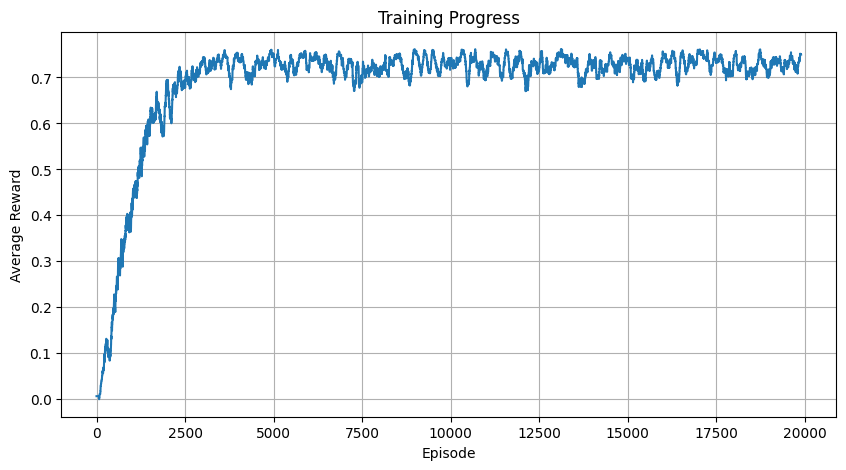

In [10]:
from utils import plot_rewards_curve
plot_rewards_curve(rewards_per_episode)

# 测试

In [11]:
env = gym.make("FrozenLake-v1", render_mode="human", is_slippery=False)
state, _ = env.reset()
gain = 0
import time
while True:
    action = q_values[state].argmax()
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    env.render()
    time.sleep(1)
    gain += reward
    if done:
        break
print("total return: ", gain)

total return:  1


In [12]:
# directions = {0: "←", 1: "↓", 2: "→", 3: "↑"}
q_values

array([[0.34977998, 0.69201874, 0.38484265, 0.36308901],
       [0.10639096, 0.        , 0.51092379, 0.08213673],
       [0.19382409, 0.61898712, 0.12802526, 0.17765466],
       [0.2210658 , 0.        , 0.13549959, 0.06133826],
       [0.49571744, 0.75206804, 0.        , 0.43355516],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.77935826, 0.        , 0.36866192],
       [0.        , 0.        , 0.        , 0.        ],
       [0.58556387, 0.        , 0.81393054, 0.50047411],
       [0.65438137, 0.87616003, 0.7894722 , 0.        ],
       [0.52495008, 0.9268708 , 0.        , 0.41168273],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.76629491, 0.94287192, 0.74648843],
       [0.78765371, 0.8953573 , 1.        , 0.81493756],
       [0.        , 0.        , 0.        , 0.        ]])

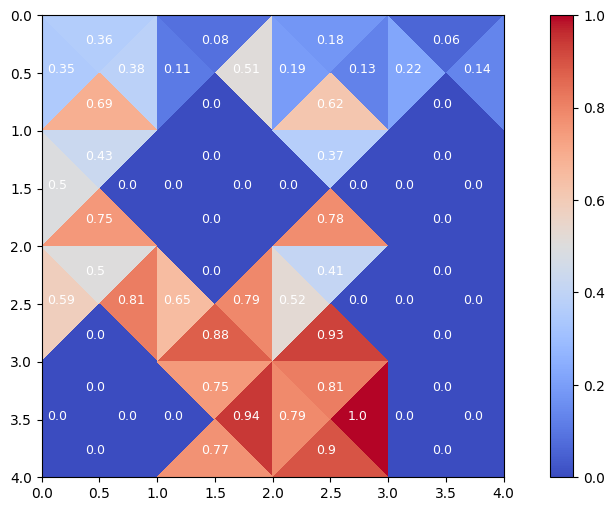

In [13]:
# 可视化动作价值
from utils import plot_action_value
plot_action_value(q_values)

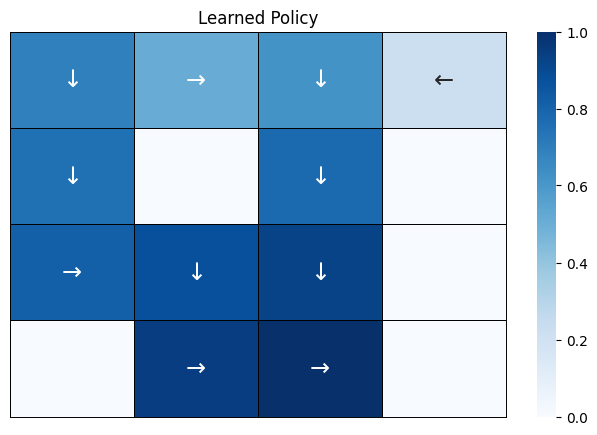

In [14]:
# 可视化动作策略
from utils import plot_policy_map
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)
env.reset()
plot_policy_map(q_values, env)